# χ² Comparison

In [1]:
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.ts_collection import TSCollection, TSSubset
from src.ts_packets import Packet, Unwrapping, Seasonality, SNR

## Choose Dataset

### Toscana Dataset

In [2]:
### -------- TS Toscana
generaldata_folder = "/mnt/DATI_PC/AA1_PROGETTI/PS_DATA/Real/"
collection_folder = "Toscana_2/"
collection_file = "TOSCANA_ps.tsc"

### Cazzaso Dataset

In [7]:
# ### -------- TS Cazzaso
generaldata_folder = "/mnt/DATI_PC/AA1_PROGETTI/PS_DATA/Real/"
collection_folder = "Cazzaso_2/"
collection_file = "Cazzaso.tsc"

### Brennero Dataset

In [3]:
### -------- TS Brennero
generaldata_folder = "/mnt/DATI_PC/AA1_PROGETTI/PS_DATA/Real/"
collection_folder = "Brennero/"
# collection_file = "BrenneroNoReUnwr4DIF.mat"
collection_file = "BrenneroReUnwr4DIF.mat"
# ts_number_list = list(range(37, 50))
ts_number_list = [37, 44]

## Define Parameters

In [3]:

# # time series Selection Parameters
kd_min = 4 # select time series with at least kd_min phase jumps
m = 1 # chosen_timeseries_number
plot_ts = 1

unwrapping_packets = {}
chi2_packets = {}
pol_degree_max = 4 # max degree of fitting model

## Create time series collection 

In [4]:
chosen_unwrapping_name = 'cplexmeanpoly_10' # choose the name of the time series collection
# chosen_unwrapping_name = 'cplexmeanpoly_reg'

tscollection = TSCollection()
tscollection.load(generaldata_folder + collection_folder + collection_file)

# Always present....is overwritten later
collection_subset = TSSubset(tscollection.get_collection_dict(), list(range(0,2)))



File read successfully!
Keys in the data dictionary:
  absolute_timeline: Series with shape (274,)
  u: ndarray with shape (74977, 274)
  w: ndarray with shape (74977, 274)
  kd: ndarray with shape (74977, 274)
  relative_timeline: ndarray with shape (274,)
  name: TOSCANA_ps
  folder: /mnt/DATI_PC/AA1_PROGETTI/PS_DATA/Real/Toscana_2/
Subcollection created successfully!


## Unwrap and Save results - If time series was already unwrapped jump to the next step (Open unwrapped data)

### Create the subcollection.
##### Extract time series from the global time series collection to unwrap. It's possible to choose among different criteria of extraction.

#### If you want to choose a single time series

In [14]:
# For Toscana Collection use ts_number from 0 to 74977
# For Cazzaso Collection use ts_number from 0 to 1970
# For Cazzaso Collection use ts_number from 0 to 778


# # ts_number = 33869 # no phase jump
# # ts_number = 27000 # no phase jump
# # ts_number = 62158 # no phase jump
ts_number = 16633 # no phase jump


ts_number_list = [ts_number]
collection_subset = TSSubset(tscollection.get_collection_dict(), ts_number_list)

Subcollection created successfully!


#### If you want to choose a list of time series

In [30]:
# For Toscana Collection use ts_number from 0 to 74977
# For Cazzaso Collection use ts_number from 0 to 1970
# For Cazzaso Collection use ts_number from 0 to 778


#ts_number_list = [77, 2453, 22303, 26966, 27831, 34247, 50477, 11453, 26071, 17560, 34567, 41138, 34348, 35205, 35623, 38047, 56539, 33646, 16476, 16729]
# ts_number_list = [77, 11453, 26071, 17560, 34348, 35205, 35623, 38047, 56539, 33646, 16476, 16729]
ts_number_list = [16633, 16677, 17515, 16727]


#ts_number_list = list(range(0,9))

# # ts_number_list = list(np.random.randint(tscollection.collection_size, size=20))
collection_subset = TSSubset(tscollection.get_collection_dict(), ts_number_list)

Subcollection created successfully!


#### If you want to extract time series with at least kd_min phase jumps

In [5]:
# # time series Selection Parameters
kd_min = 3 # select time series with at least kd_min phase jumps
m = 20 # how many time series to unwrap?
plot_ts = 1


kd = tscollection.get_data('kd')
mask = ((kd >= kd_min) | (kd <= -kd_min)).any(axis=1)
selected_indices = np.where(mask)[0].tolist()  # Ottieni gli indici numerici
print(f'\nTotal number of time series with abs(kd) >= {kd_min}: {len(selected_indices)}\n')

selected_indices = np.array(selected_indices)
m = min(m, len(selected_indices))
ts_number_list = np.random.choice(selected_indices, size=m, replace=False)

collection_subset = TSSubset(tscollection.get_collection_dict(), ts_number_list)


Total number of time series with abs(kd) >= 3: 696

Subcollection created successfully!


### Unwrap and Save

In [6]:
starttime = datetime.now()
# ## ------------- Cycle over different polynomial degree -------------------

# ## ------------- Unwrap and Save
print("\nPlease Wait.....\n")
for pol_degree in range(1,pol_degree_max + 1):
    partialtime = datetime.now()
    # packet_id = f'pol_degree_{pol_degree}'
    packet_id = f'{pol_degree}'    
    # # # # ############ GENERATE NEW CPLEXmeanpoly_UNWRAPPING ++++++++++++++++++++++++++++
    # # # # # # 1. Define the unwrapping object 2. Create new Unwrapping data
    unwrap_param = {'min_t_index': 0, 'max_t_index': 300, 'max_slope': 16,
                    'polynomial_degree': pol_degree, "n_cpu": 4}
    unwrapping_packets[packet_id] = Unwrapping(collection_subset) # parameter: ts collection linked to this unwrapping 
    unwrapping_packets[packet_id].new(unwrapping_name = f'{chosen_unwrapping_name}_degree{pol_degree}',
                             unwrapping_algo = 'CPLEXmeanpoly_unwrap', unwrap_param = unwrap_param,
                             unwrapping_note=f"Used polynomial model with degree p = {pol_degree}")
    unwrapping_packets[packet_id].save()
    print(f"Polynomial degree {pol_degree} time: {(datetime.now()- partialtime)}")
    
print("TOTAL TIME: ",datetime.now()- starttime)



Please Wait.....

File /mnt/DATI_PC/AA1_PROGETTI/PS_DATA/Real/Toscana_2/TOSCANA_ps_cplexmeanpoly_10_degree1.unw saved successfully!
Polynomial degree 1 time: 0:00:33.699241
File /mnt/DATI_PC/AA1_PROGETTI/PS_DATA/Real/Toscana_2/TOSCANA_ps_cplexmeanpoly_10_degree2.unw saved successfully!
Polynomial degree 2 time: 0:00:42.855451
File /mnt/DATI_PC/AA1_PROGETTI/PS_DATA/Real/Toscana_2/TOSCANA_ps_cplexmeanpoly_10_degree3.unw saved successfully!
Polynomial degree 3 time: 0:00:52.478276
File /mnt/DATI_PC/AA1_PROGETTI/PS_DATA/Real/Toscana_2/TOSCANA_ps_cplexmeanpoly_10_degree4.unw saved successfully!
Polynomial degree 4 time: 0:01:01.261142
TOTAL TIME:  0:03:10.294527


## Open the unwrapped data (if already saved)

In [7]:
# # # ############ OPEN UNWRAPPING ++++++++++++++++++++++++++++
   
for pol_degree in range(1,pol_degree_max + 1): 
    
    # packet_id = f'pol_degree_{pol_degree}'
    packet_id = f'{pol_degree}'
    unwrapping_packets[packet_id] = Unwrapping(collection_subset)
    unwrapping_packets[packet_id].load(f'{chosen_unwrapping_name}_degree{pol_degree}.unw')
    

Packet /mnt/DATI_PC/AA1_PROGETTI/PS_DATA/Real/Toscana_2/TOSCANA_ps_cplexmeanpoly_10_degree1.unw opened successfully!
Packet /mnt/DATI_PC/AA1_PROGETTI/PS_DATA/Real/Toscana_2/TOSCANA_ps_cplexmeanpoly_10_degree2.unw opened successfully!
Packet /mnt/DATI_PC/AA1_PROGETTI/PS_DATA/Real/Toscana_2/TOSCANA_ps_cplexmeanpoly_10_degree3.unw opened successfully!
Packet /mnt/DATI_PC/AA1_PROGETTI/PS_DATA/Real/Toscana_2/TOSCANA_ps_cplexmeanpoly_10_degree4.unw opened successfully!


## Calculate  χ² and save results

##### If already saved jump to the next step

In [15]:
for pol_degree in range(1,pol_degree_max + 1): 
    
    # packet_id = f'pol_degree_{pol_degree}'
    packet_id = f'{pol_degree}'
    unwrapping_packets[packet_id] = Unwrapping(collection_subset)
    unwrapping_packets[packet_id].load(f'{chosen_unwrapping_name}_degree{pol_degree}.unw')

# # #     ###################### Calculate  χ² ###################################
    ts_length = unwrapping_packets[packet_id].get_data('absolute_timeline').shape[0]
    # print(ts_length)
    
    residuals = unwrapping_packets[packet_id].get_data('u').to_numpy() - unwrapping_packets[packet_id].get_data('m').to_numpy()  # shape: (n, ts_length)
    
    chi2 = np.sum(residuals**2, axis=1)                    # sum per riga
    dof = ts_length - (pol_degree + 1)
    chi2_reduced = chi2 / dof
    
    ts_list = unwrapping_packets[packet_id].get_data('u').index
    chi2_data_df = pd.DataFrame(chi2, columns = ['chi2'], index=ts_list)
    chi2_data_df['chi2_reduced'] = chi2_reduced
    
#     # -- create and save packet with χ² results ---------
    chi2_packets[packet_id] = Packet(collection_subset)
    chi2_packets[packet_id].set_data('name', chosen_unwrapping_name + f'_degree{pol_degree}_chi2')
    chi2_packets[packet_id].set_data('note', f'chi2 measured for polynomial degree {pol_degree}')
    chi2_packets[packet_id].set_data('chi2_data', chi2_data_df)
    chi2_packets[packet_id].save()
    

Packet /mnt/DATI_PC/AA1_PROGETTI/PS_DATA/Real/Toscana_2/TOSCANA_ps_cplexmeanpoly_10_degree1.unw opened successfully!
File /mnt/DATI_PC/AA1_PROGETTI/PS_DATA/Real/Toscana_2/TOSCANA_ps_cplexmeanpoly_10_degree1_chi2.unw saved successfully!
Packet /mnt/DATI_PC/AA1_PROGETTI/PS_DATA/Real/Toscana_2/TOSCANA_ps_cplexmeanpoly_10_degree2.unw opened successfully!
File /mnt/DATI_PC/AA1_PROGETTI/PS_DATA/Real/Toscana_2/TOSCANA_ps_cplexmeanpoly_10_degree2_chi2.unw saved successfully!
Packet /mnt/DATI_PC/AA1_PROGETTI/PS_DATA/Real/Toscana_2/TOSCANA_ps_cplexmeanpoly_10_degree3.unw opened successfully!
File /mnt/DATI_PC/AA1_PROGETTI/PS_DATA/Real/Toscana_2/TOSCANA_ps_cplexmeanpoly_10_degree3_chi2.unw saved successfully!
Packet /mnt/DATI_PC/AA1_PROGETTI/PS_DATA/Real/Toscana_2/TOSCANA_ps_cplexmeanpoly_10_degree4.unw opened successfully!
File /mnt/DATI_PC/AA1_PROGETTI/PS_DATA/Real/Toscana_2/TOSCANA_ps_cplexmeanpoly_10_degree4_chi2.unw saved successfully!


## Compare χ² values

##### Open χ² packets and Compare χ² values for different models and choose the minimum value

In [16]:
# ------------- Test χ² packets
chi2_packets = {}
for pol_degree in range(1, pol_degree_max + 1): 
    # packet_id = f'pol_degree_{pol_degree}'
    packet_id = f'{pol_degree}'
    
    # ----- Load chi2 data ---------------------
    chi2_packets[packet_id] = Packet(collection_subset)
    chi2_packets[packet_id].load(chosen_unwrapping_name + f'_degree{pol_degree}_chi2.unw')
    
## ------------- Merge and compare results     
chi2_dict = {}
chi2_reduced_dict = {}

# Loop through the stored packets
for pol_degree in range(1, pol_degree_max + 1):
    packet_id = f'{pol_degree}'
    label = f'{pol_degree}'

    # Extract arrays
    chi2_array = chi2_packets[packet_id].get_data('chi2_data')['chi2']
    chi2_reduced_array = chi2_packets[packet_id].get_data('chi2_data')['chi2_reduced']

    # Store them in the dicts using the label
    chi2_dict[label] = chi2_array
    chi2_reduced_dict[label] = chi2_reduced_array

# # Convert to DataFrames
df_chi2 = pd.DataFrame(chi2_dict)
df_chi2_reduced = pd.DataFrame(chi2_reduced_dict)


# For df_chi2
df_chi2['min_pol_degree'] = df_chi2.idxmin(axis=1).astype(str).str.extract(r'(\d+)').astype(int)
df_chi2['variance'] = df_chi2.var(axis=1)

# For df_chi2_reduced
df_chi2_reduced['min_pol_degree'] = df_chi2_reduced.idxmin(axis=1).astype(str).str.extract(r'(\d+)').astype(int)
df_chi2_reduced['variance'] = df_chi2_reduced.var(axis=1)
# print(df_chi2.head)

Packet /mnt/DATI_PC/AA1_PROGETTI/PS_DATA/Real/Toscana_2/TOSCANA_ps_cplexmeanpoly_10_degree1_chi2.unw opened successfully!
Packet /mnt/DATI_PC/AA1_PROGETTI/PS_DATA/Real/Toscana_2/TOSCANA_ps_cplexmeanpoly_10_degree2_chi2.unw opened successfully!
Packet /mnt/DATI_PC/AA1_PROGETTI/PS_DATA/Real/Toscana_2/TOSCANA_ps_cplexmeanpoly_10_degree3_chi2.unw opened successfully!
Packet /mnt/DATI_PC/AA1_PROGETTI/PS_DATA/Real/Toscana_2/TOSCANA_ps_cplexmeanpoly_10_degree4_chi2.unw opened successfully!


## Plot the unwrapped time series with the best fit model

Subcollection created successfully!


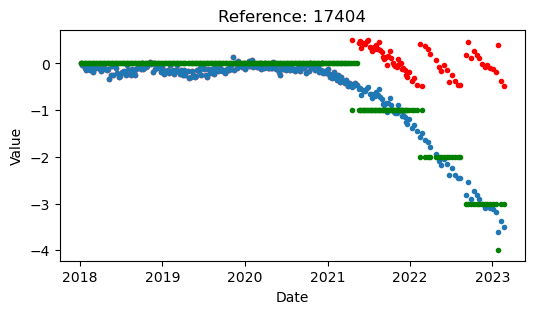

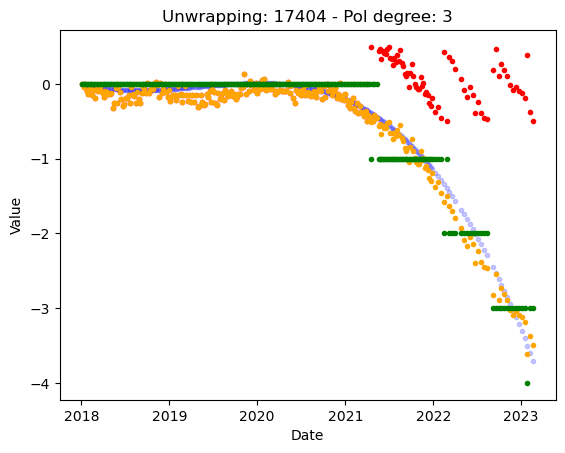

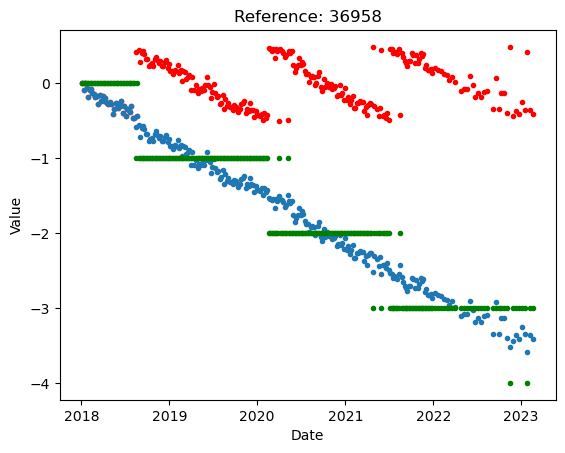

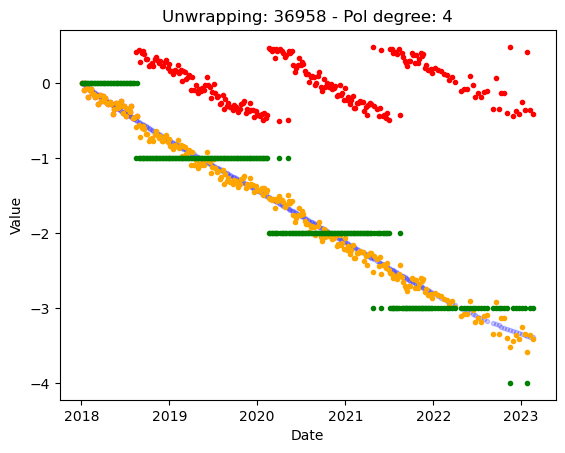

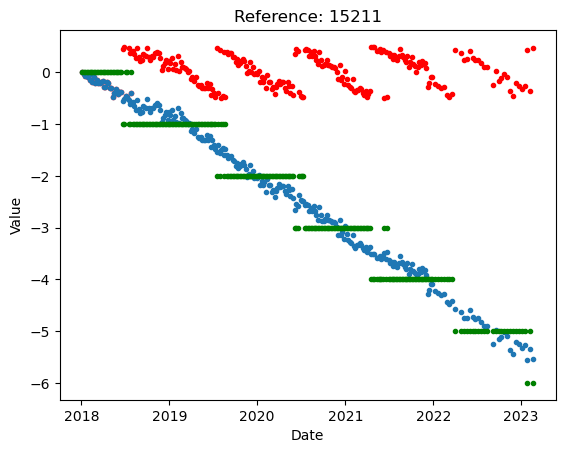

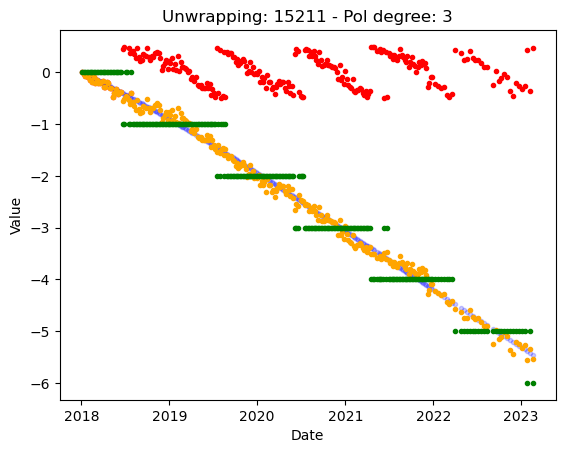

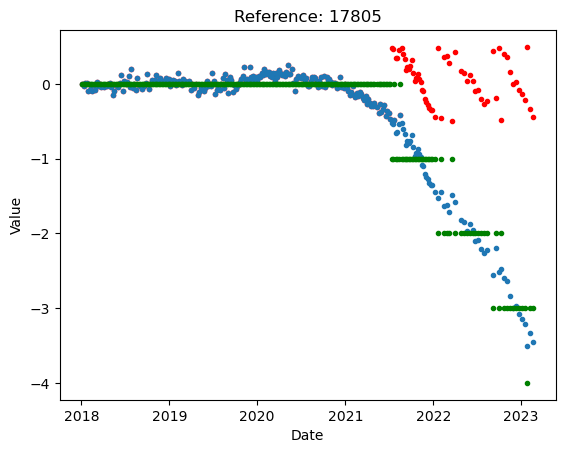

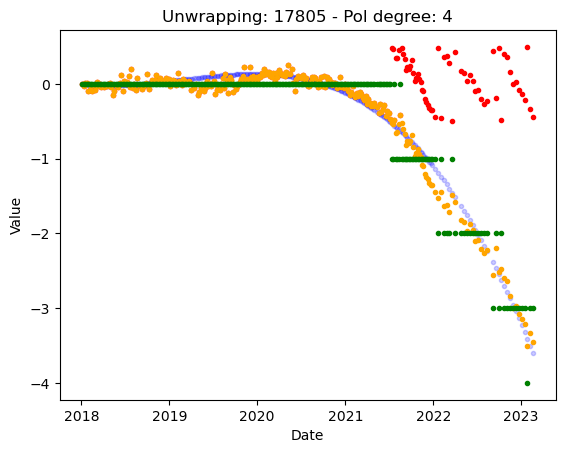

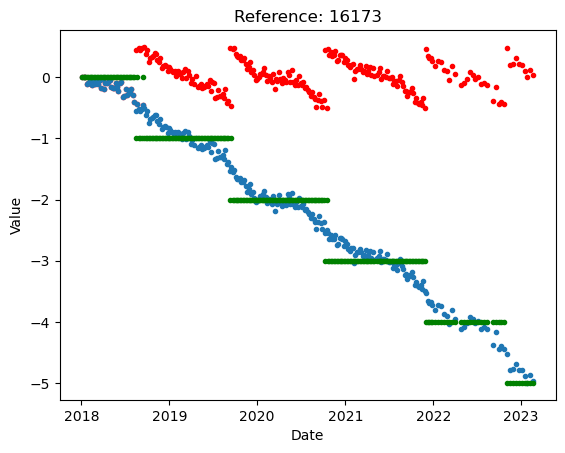

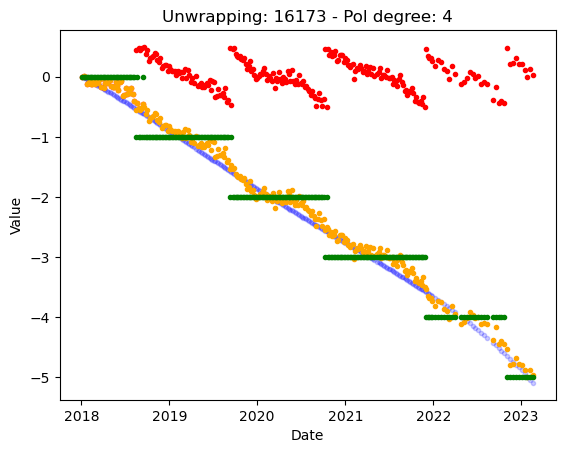

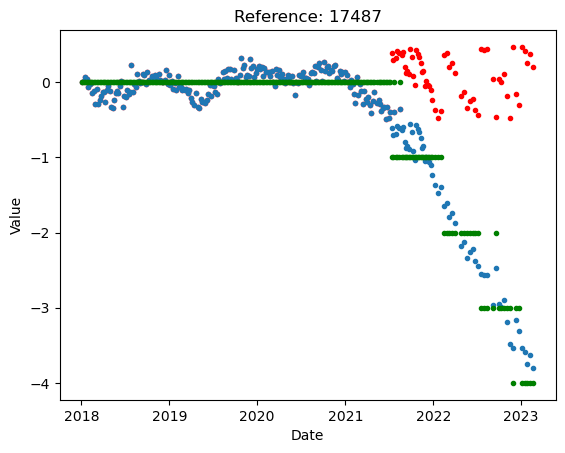

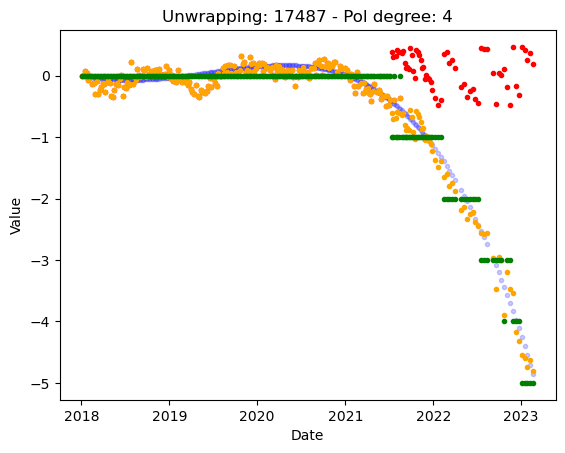

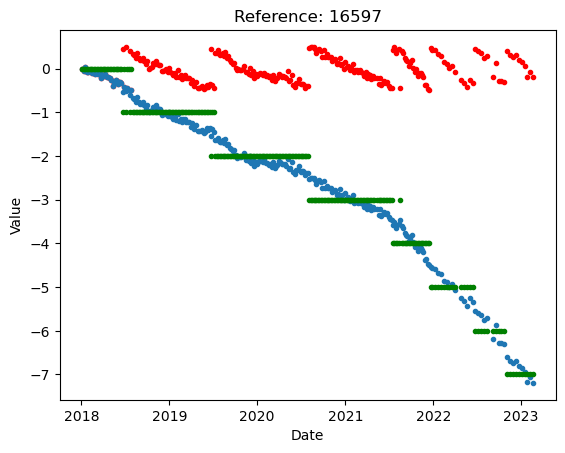

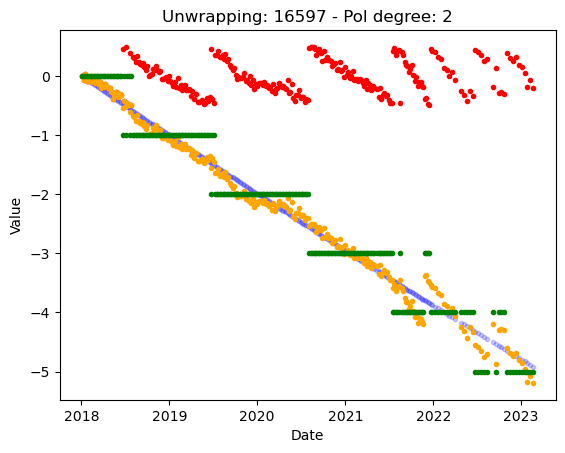

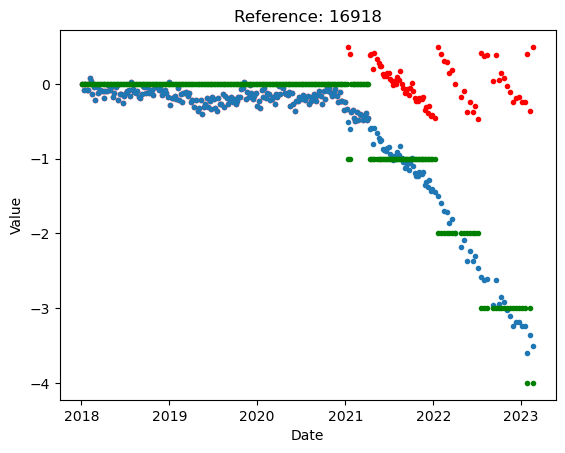

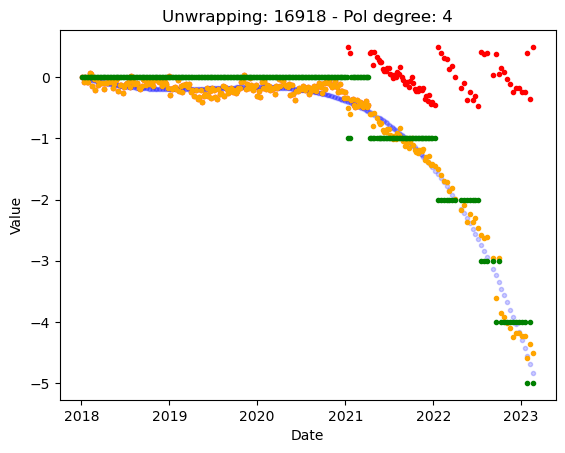

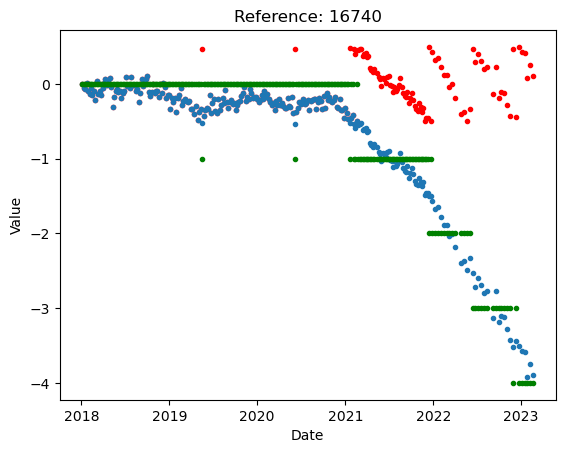

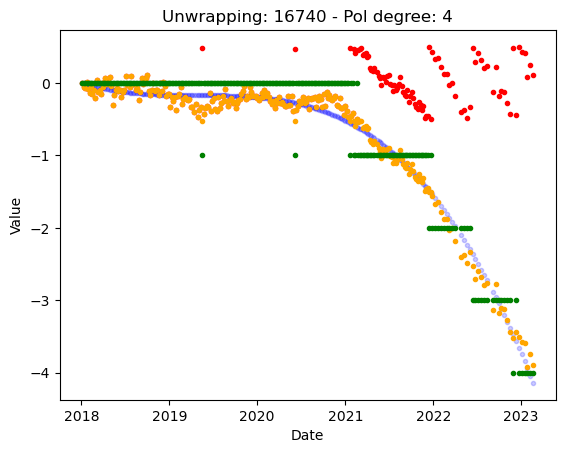

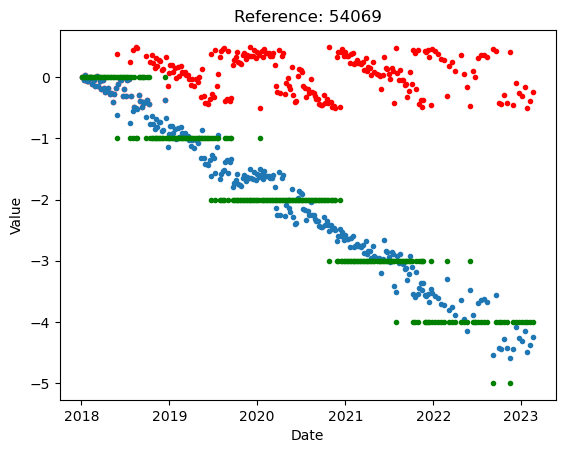

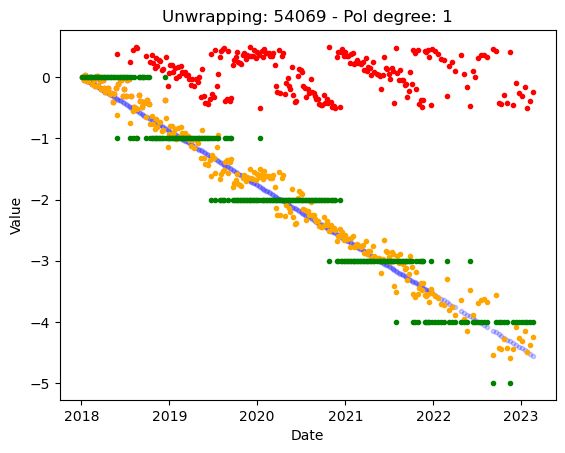

In [20]:
# # # # # # # ############ PLOT UNWRAPPING ++++++++++++++++++++++++++++
ts_number_list = list(df_chi2.index)
collection_subset = TSSubset(tscollection.get_collection_dict(), ts_number_list)



#     # poly_order = 4
plt.figure(figsize=(6, 3))
for ts in ts_number_list:
    poly_order = df_chi2.loc[ts, 'min_pol_degree']
    # poly_order = 4
#     # for ts in [50150]:
#     # for ts in acc1[acc1 < 70].index:  
    wt = collection_subset.get_data('w').loc[ts]
    ut = collection_subset.get_data('u').loc[ts]
    kd_ref = collection_subset.get_data('kd').loc[ts]
    
    wc = unwrapping_packets['1'].get_data('w').loc[ts]   
    uc = unwrapping_packets[f'{poly_order}'].get_data('u').loc[ts]
    kd_calc = (np.round(wc - uc)).astype(int)  

    plt.plot(collection_subset.absolute_timeline, wt, 'r.', label="Original Series")
    plt.plot(collection_subset.absolute_timeline, ut, '.', label="Original Series")
    plt.plot(collection_subset.absolute_timeline, -kd_ref, 'g.', label="Original Series")

    plt.title(f"Reference: {ts}")
    # plt.legend()
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.show()
    
    plt.plot(collection_subset.absolute_timeline, wc, 'r.', label="Original Series")
    plt.plot(collection_subset.absolute_timeline, 
             unwrapping_packets[f'{poly_order}'].get_data('m').loc[ts],
             'b.', alpha=0.2, label="Original Series")
    plt.plot(collection_subset.absolute_timeline, uc, '.', color = 'orange', label="Original Series")
    plt.plot(collection_subset.absolute_timeline, -kd_calc, 'g.', label="Original Series")

    plt.title(f"Unwrapping: {ts} - Pol degree: {poly_order}")
    # plt.legend()
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.show()